## 1. 밑준비

SAM3를 설치하고 Hugging Face에 로그인하겠습니다. SAM3는 사진에서 사람·차량 같은 객체를 찾아 주는 데 쓸 거예요. 같은 런타임에서 이미 마치셨다면 해당 셀은 건너뛰셔도 괜찮습니다.

### 1-1. SAM3 설치

Colab의 기본 PyTorch/CUDA/OpenCV 환경은 그대로 두고, SAM3만 `/content/sam3`에 살짝 설치하겠습니다. 설치 후 NumPy 관련 warning이 보이더라도 너무 놀라지 마세요! 런타임을 한 번 재시작한 뒤 다음 셀부터 이어서 실행하면 됩니다.

In [1]:
!git clone https://github.com/facebookresearch/sam3.git /content/sam3
!pip install -e "/content/sam3[notebooks]"

print("SAM3 설치가 끝났습니다.")

Cloning into '/content/sam3'...
remote: Enumerating objects: 1417, done.
remote: Total 1417 (delta 0), reused 0 (delta 0), pack-reused 1417 (from 1)
Receiving objects: 100% (1417/1417), 60.45 MiB | 24.29 MiB/s, done.
Resolving deltas: 100% (550/550), done.
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 102.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements.

SAM3 설치가 끝났습니다.


### 1-2. Hugging Face 로그인

SAM3 checkpoint는 Hugging Face의 gated repository에 살고 있어서, 모델을 내려받기 전에 먼저 로그인이라는 인사를 건네야 합니다. https://huggingface.co/facebook/sam3 에 접속해 access 조건에 동의한 뒤, fine-grained token에 public gated repository 읽기 권한을 켜고 아래 셀에서 로그인하면 준비 끝이에요!

In [1]:
from huggingface_hub import notebook_login

# facebook/sam3 접근 권한이 있는 Hugging Face token으로 로그인합니다.
# https://huggingface.co/facebook/sam3 에서 access 조건에 먼저 동의해야 합니다.
notebook_login()

### 1-3. imports와 설정

SAM3 import 경로와 기본 라이브러리, 연산 device를 설정합니다. 학습·추론 데이터, 찾을 객체(클래스), epoch 처럼 자주 바꾸는 값은 다음 설정 셀 한곳에 모아 두었어요.

In [3]:
import sys
from pathlib import Path

# SAM3는 /content/sam3 에 설치돼 있으니, 거기서 import할 수 있도록 경로를 추가합니다.
SAM3_ROOT = Path("/content/sam3")
if str(SAM3_ROOT) not in sys.path:
    sys.path.insert(0, str(SAM3_ROOT))

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image

# SAM3 모델을 만들고, 사진에 text prompt를 적용해 객체를 찾아 주는 도구들이에요.
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

# GPU가 있으면 GPU(cuda), 없으면 CPU를 씁니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


자주 바꾸게 될 값들은 이 설정 셀 한곳에 모아 두었어요. 크게 네 묶음입니다.

 - 데이터 위치: 학습용 사진과 테스트용 사진을 각각 구글 드라이브에서 받아 `TRAIN_ROOT`·`TEST_ROOT` 폴더에 풀어 둡니다. 둘을 나눠 두는 건, 모델이 "공부한 사진"이 아니라 "처음 보는 사진"에서도 잘 맞히는지 확인하기 위해서예요.

  - 찾을 객체(CLASSES): S SAM3에게 "이런 것들을 찾아 줘"라고 건넬 단어 목록이에요. 사람(person)이나 차량(vehicle), 빨간불·초록불 신호등처럼 go/stop 판단에 도움이 될 만한 것들이 담겨 있습니다. 우리 모델은 사진을 통째로 보지 않고 여기 적힌 객체들의 위치와 크기를 단서로 받습니다.

  - 입력 길이(INPUT_DIM): 객체 하나를 vector로 표현할 거예요. "어떤 종류인지"를 클래스 수만큼의 one-hot으로, 거기에 박스의 위치·크기 4개 값을 이어 붙입니다. 그래서 객체 1개당 숫자 개수는 `N_PER_OBJECT = 클래스 수 + 4`가 돼요. 그리고 한 사진에서 객체를 최대 `MAX_OBJECTS`개까지 보기로 했으니, 이 vector들을 쭉 이어 붙이면 사진 한 장은 길이 `INPUT_DIM = MAX_OBJECTS × N_PER_OBJECT`짜리 vector 하나가 됩니다. 이게 곧 MLP에 들어갈 입력의 길이예요.

  - label/학습 설정: 정답 go/stop은 모델이 다루기 쉽게 0/1로 바꿔 둡니다. 그 아래 ``BATCH_SIZE`(한 번에 몇 장씩), `LEARNING_RATE`(한 걸음을 얼마나 크게)는 학습을 돌릴 때 쓰는 값이에요.

실험에 사용되는 변수는 대부분 여기서 미리 정의해둡니다. 따라서, 여기 값만 바꾸면, 모델이 보는 단서나 학습 방식이 달라집니다.

In [9]:
# ── 데이터 위치 ─────────────────────────────────────────────
# 학습 데이터: go/stop이 섞인 운전 사진 (구글 드라이브)
TRAIN_URL = "https://drive.google.com/file/d/1kqlAqGpbjE85e9MSABbxwkD77JbrsNs8/view?usp=drive_link"
TRAIN_ROOT = "/content/sam3_go_stop_train"
# 테스트 데이터: 학습에 쓰지 않은 사진 (구글 드라이브)
TEST_URL = "https://drive.google.com/file/d/1WAowcv523-z3mw2oKHS5uVL6zxXKRvwl/view?usp=drive_link"
TEST_ROOT = "/content/sam3_go_stop_test"

# ── SAM3로 찾을 객체(클래스) ────────────────────────────────
# 이 prompt 목록이 곧 "어떤 단서를 볼지"를 정합니다. 사람이 직접 고른 부분이에요(= Software 1.0).
# 빨간불/초록불을 나눈 이유: 빨간불은 '정지', 초록불은 '진행'의 단서가 되기 때문이에요.
# 여기 단어를 바꾸거나 더하면 모델이 보는 단서가 달라집니다. (예: traffic cone -> barrier)
CLASSES = ["person", "bicycle", "vehicle", "red traffic light", "green traffic light", "stop sign", "animal", "traffic cone"]

# ── 검출 / feature 설정 ─────────────────────────────────────
HARVEST_CONFIDENCE = 0.5   # SAM3가 이 점수 이상으로 확신한 객체만 사용 (높일수록 확실한 것만)
MAX_OBJECTS = 20           # 한 사진에서 feature로 쓸 최대 객체 수 (이만큼만 보고 나머지는 버림)
N_PER_OBJECT = len(CLASSES) + 4         # 객체 1개당 숫자 개수 = one-hot(클래스 수) + 박스 4값
INPUT_DIM = MAX_OBJECTS * N_PER_OBJECT  # MLP 입력 길이 (객체 20개를 쭉 이어 붙인 길이)

# ── 라벨 / 학습 설정 ────────────────────────────────────────
LABEL_TO_IDX = {"go": 0, "stop": 1}   # 정답을 숫자로: go=0, stop=1
IDX_TO_LABEL = {0: "go", 1: "stop"}   # 숫자를 다시 글자로 (결과 출력용)
BATCH_SIZE = 8         # 한 번에 몇 장씩 묶어 학습할지
LEARNING_RATE = 0.001  # 학습 속도(보폭)

print("INPUT_DIM =", INPUT_DIM)
print("슝~")

INPUT_DIM = 240
슝~


## 2. 학습 데이터 받기

먼저 모델을 학습시킬 운전 사진을 구글 드라이브에서 받겠습니다. 파일 이름에 정답이 숨어 있어요 — 이름에 go가 들어 있으면 정답은 go(0), stop이 들어 있으면 정답은 stop(1)이랍니다. 이 정답을 박스 feature와 함께 학습에 씁니다.

In [ ]:
!pip -q install gdown
os.makedirs(TRAIN_ROOT, exist_ok=True)
# gdown으로 구글 드라이브 zip을 받아 압축을 풉니다.
!gdown --fuzzy "{TRAIN_URL}" -O /content/train.zip
!unzip -q -o /content/train.zip -d "{TRAIN_ROOT}"


# 파일 이름으로 (이미지 경로, 라벨) 목록을 만듭니다.
# 파일 이름에 정답이 들어 있어요: "stop"이 있으면 1, "go"가 있으면 0.
def list_images_with_labels(root):
    items = []
    for p in sorted(Path(root).rglob("*")):       # 폴더 안 모든 파일을 훑으며
        if p.suffix.lower() not in (".jpg", ".jpeg", ".png"):
            continue                               # 이미지 파일만 사용
        name = p.name.lower()
        if "stop" in name:
            items.append((str(p), LABEL_TO_IDX["stop"]))
        elif "go" in name:
            items.append((str(p), LABEL_TO_IDX["go"]))
    return items


train_items = list_images_with_labels(TRAIN_ROOT)
n_go = sum(1 for _, y in train_items if y == 0)
n_stop = sum(1 for _, y in train_items if y == 1)
print(f"학습 이미지: {len(train_items)}장 (go {n_go} / stop {n_stop})")

Downloading...
From (original): https://drive.google.com/uc?id=1kqlAqGpbjE85e9MSABbxwkD77JbrsNs8
From (redirected): https://drive.google.com/uc?id=1kqlAqGpbjE85e9MSABbxwkD77JbrsNs8&confirm=t&uuid=9b56cc42-3567-423b-b574-c012ca777a1a
To: /content/train.zip
100% 158M/158M [00:01<00:00, 155MB/s]
학습 이미지: 60장 (go 30 / stop 30)


그럼 어떤 이미지로 구성되어 있는지 학습 이미지를 확인해 봅시다

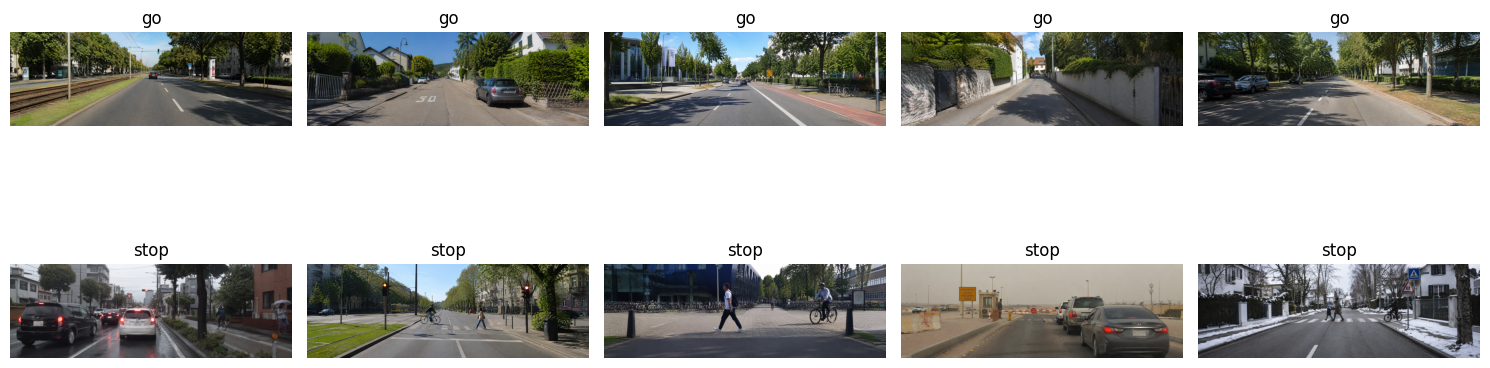

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# 학습 데이터 목록을 go / stop으로 나눕니다. (파일명에 "go"/"stop"이 들어 있습니다.)
train_items = list_images_with_labels(TRAIN_ROOT)          # [(경로, 라벨), ...]
go_paths   = [p for p, label in train_items if label == 0][:5]   # go 5장
stop_paths = [p for p, label in train_items if label == 1][:5]   # stop 5장

# 윗줄에 go 5장, 아랫줄에 stop 5장 → 2행 5열로 배치합니다.
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, path in enumerate(go_paths):
    axes[0][i].imshow(Image.open(path))
    axes[0][i].set_title("go")
    axes[0][i].axis("off")

for i, path in enumerate(stop_paths):
    axes[1][i].imshow(Image.open(path))
    axes[1][i].set_title("stop")
    axes[1][i].axis("off")

plt.tight_layout()
plt.show()

## 3. SAM3로 박스 feature 만들기

이제 SAM3가 등장합니다. 한 사진에서 CLASSES의 객체들을 찾아, 각 객체의 bounding box를 고정 길이 숫자(feature)로 바꾸는 helper를 정의하겠습니다.

검출된 박스 개수는 사진마다 다른데, MLP 입력은 길이가 고정돼야 해요. 그래서 이렇게 합니다.

- `detect_objects()`: 한 prompt(예: "person")로 마스크와 score를 얻습니다.
- `mask_iou()`: 두 마스크가 얼마나 겹치는지(IoU)를 계산합니다.
- `build_feature_vector()`: 모든 클래스를 검출 → 겹치는 건 점수 높은 것만 남기고 → 넓이가 큰(가까운) 순으로 최대 `MAX_OBJECTS`개만 골라 → 객체마다 [클래스 one-hot, 중심x, 아래쪽 y, 너비, 높이]로 정리하고, 모자라면 0으로 채워 고정 길이 벡터로 만듭니다.

아래쪽 y와 넓이를 쓰는 이유는, 운전 화면에선 가까운 물체일수록 화면 아래에 크게 잡혀서 "가까움"의 단서가 되기 때문이에요.

In [10]:
# 한 prompt(예: "person")로 사진에서 객체 마스크와 점수(score)를 얻습니다.
def detect_objects(processor, image, prompt, confidence=HARVEST_CONFIDENCE):
    state = processor.set_image(image)                             # 사진을 SAM3에 올림
    processor.set_confidence_threshold(confidence)                 # 검출 기준 점수 설정
    processor.reset_all_prompts(state)                             # 이전 prompt 흔적 지우기
    state = processor.set_text_prompt(prompt=prompt, state=state)  # 텍스트 prompt 적용
    return state.get("masks", []), state.get("scores", [])


# 두 마스크가 얼마나 겹치는지(IoU). 같은 물체가 두 번 잡혔는지 확인할 때 씁니다.
def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()   # 둘 다 켜진 픽셀 수 (교집합)
    union = np.logical_or(a, b).sum()    # 하나라도 켜진 픽셀 수 (합집합)
    return inter / union if union > 0 else 0.0


# 사진 한 장 -> 고정 길이(INPUT_DIM) feature 벡터로 바꿉니다.
def build_feature_vector(processor, image, iou_thr=0.5):
    # 1) 모든 클래스를 검출해, 객체 하나를
    #    [클래스번호, score, 넓이, 중심x, 아래y, 너비, 높이, mask]로 모읍니다.
    dets = []
    for class_idx, prompt in enumerate(CLASSES):
        masks, scores = detect_objects(processor, image, prompt)
        for m, s in zip(masks, scores):
            # 마스크를 numpy 2차원 boolean 배열로 정리
            m = m.detach().cpu().numpy() if isinstance(m, torch.Tensor) else np.asarray(m)
            m = np.squeeze(m).astype(bool)
            ys, xs = np.where(m)             # 마스크가 켜진 픽셀들의 좌표
            if len(xs) == 0:
                continue                     # 빈 마스크는 건너뜀
            H, W = m.shape
            # 박스 좌표를 0~1로 정규화 (사진 크기가 달라도 같은 척도가 되도록)
            x0, x1 = xs.min() / W, xs.max() / W
            y0, y1 = ys.min() / H, ys.max() / H
            w, h = x1 - x0, y1 - y0
            cx, by = (x0 + x1) / 2, y1       # 중심 x, 아래쪽 y (가까운 물체일수록 아래·크게 잡힘)
            dets.append([class_idx, float(s), w * h, cx, by, w, h, m])

    # 2) 같은 물체가 여러 prompt에 중복으로 잡힐 수 있어요.
    #    점수 높은 순으로 보며, 이미 담은 것과 많이 겹치면(IoU 큼) 버립니다. (중복 제거)
    dets.sort(key=lambda d: d[1], reverse=True)
    kept = []
    for d in dets:
        if all(mask_iou(d[7], k[7]) < iou_thr for k in kept):
            kept.append(d)

    # 3) 넓이가 큰(=대체로 가까운) 순으로 최대 MAX_OBJECTS개만 남깁니다.
    kept.sort(key=lambda d: d[2], reverse=True)
    kept = kept[:MAX_OBJECTS]

    # 4) 객체마다 한 줄씩 채웁니다: [클래스 one-hot..., 중심x, 아래y, 너비, 높이]
    #    객체가 MAX_OBJECTS보다 적으면 나머지 줄은 0으로 남습니다(= 빈 자리).
    feat = np.zeros((MAX_OBJECTS, N_PER_OBJECT), dtype=np.float32)
    for i, d in enumerate(kept):
        class_idx, cx, by, w, h = d[0], d[3], d[4], d[5], d[6]
        feat[i, class_idx] = 1.0                 # 어떤 클래스인지 one-hot으로 표시
        feat[i, len(CLASSES):] = [cx, by, w, h]  # 박스 위치·크기
    return feat.flatten()                        # 2차원 표를 한 줄로 펴서 MLP 입력으로


print("슝~")

슝~


SAM3 image model과 processor를 불러오겠습니다. 이 `processor`로 학습·테스트 사진에서 객체를 찾게 됩니다.

In [4]:
sam3_model = build_sam3_image_model(device=str(device), load_from_HF=True, enable_inst_interactivity=True)
processor = Sam3Processor(sam3_model, device=str(device), confidence_threshold=0.5)
print("SAM3 model loaded")

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt: reconstructing file:   0%|          |  0.00B / 3.45GB            

sam3.pt: downloading bytes:           |  0.00B            

SAM3 model loaded


## 4. 학습 데이터를 박스 feature로 변환



 모든 사진에서 feature를 뽑는 데엔 시간이 꽤 걸립니다. 그 전에, SAM3가 우리가 적어 둔 prompt들을 사진에서 실제로 잘 짚는지 한 장으로 먼저 확인해 볼게요. "person이라고 했을 때 정말 사람을 짚는지", "red traffic light가 엉뚱한 걸 잡지는 않는지"를 눈으로 점검하는 거예요.

아래 셀은 사진 한 장을 골라, `CLASSES`의 prompt마다 검출된 영역을 덧칠해 보여 줍니다. 어떤 prompt가 하나도 못 찾았다면, 그 사진에 정말 그 객체가 없어서일 수도 있고, prompt 단어가 잘 안 맞아서일 수도 있습니다.

/tmp/ipykernel_24862/1336600948.py:33: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24862/1336600948.py:33: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24862/1336600948.py:33: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24862/1336600948.py:33: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24862/1336600948.py:33: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24862/1336600948.py:33: UserWarning: Glyph 46304 (\N{HANGUL SYLLABLE DEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24862/1336600948.py:33: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  

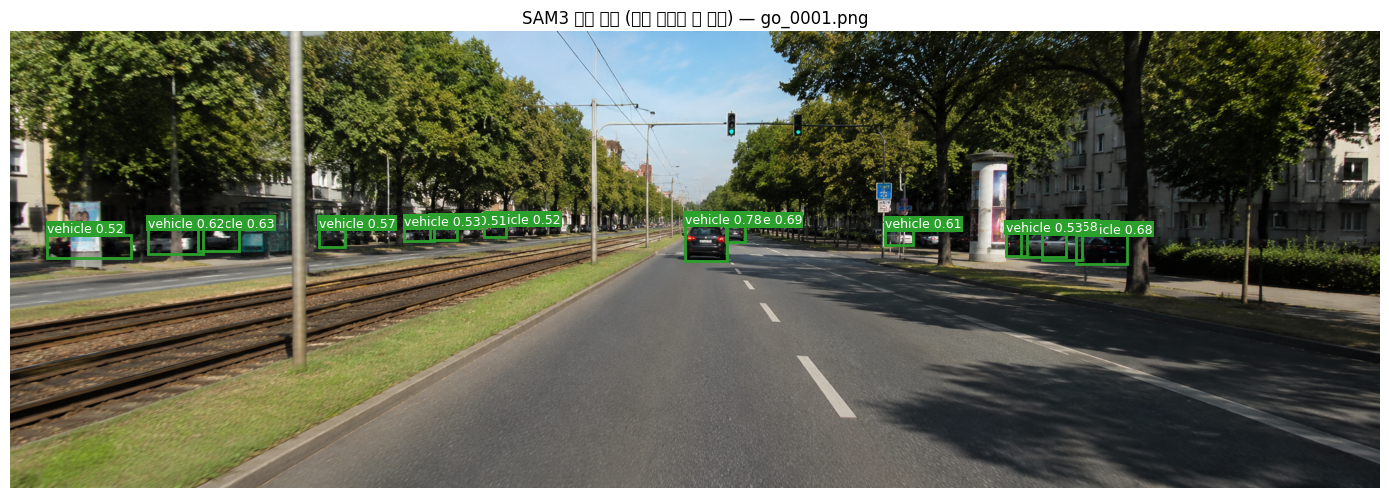

In [ ]:
import matplotlib.patches as patches

# 사진 한 장에 모든 클래스를 한꺼번에 검출해 박스로 그려 봅니다.
INDEX = 0
sample_path, _ = train_items[INDEX]
sample_image = Image.open(sample_path).convert("RGB")

# 클래스마다 다른 색을 줍니다.
colors = plt.cm.tab10(np.linspace(0, 1, len(CLASSES)))

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(sample_image)

for class_idx, prompt in enumerate(CLASSES):
    masks, scores = detect_objects(processor, sample_image, prompt)   # 이 prompt로 검출
    color = colors[class_idx]
    for m, s in zip(masks, scores):
        m = m.detach().cpu().numpy() if isinstance(m, torch.Tensor) else np.asarray(m)
        m = np.squeeze(m).astype(bool)
        ys, xs = np.where(m)
        if len(xs) == 0:
            continue
        x0, x1, y0, y1 = xs.min(), xs.max(), ys.min(), ys.max()
        # 박스를 그리고
        ax.add_patch(patches.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                       fill=False, edgecolor=color, linewidth=2))
        # 박스 위에 클래스 이름과 점수를 적습니다.
        ax.text(x0, max(y0 - 4, 0), f"{prompt} {float(s):.2f}",
                color='white', fontsize=9,
                bbox=dict(facecolor=color, edgecolor='none', pad=1))
ax.set_title(f"SAM3 검출 결과 (모든 클래스 한 번에) — {Path(sample_path).name}", fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

이제 학습 사진 한 장 한 장을 SAM3에 통과시켜 박스 feature로 바꾸겠습니다. 사진마다 객체를 찾고 정리하는 데 시간이 조금 걸리니, progress bar로 진행 상황을 보여 줄게요. 결과는 `X`(feature)와 `y`(정답)로 쌓입니다.

In [ ]:
from tqdm.auto import tqdm


# 이미지 목록을 받아, 각 사진을 feature 벡터로 바꾸고 정답과 함께 쌓습니다.
def build_feature_dataset(processor, items, desc):
    X, y = [], []
    for path, label in tqdm(items, desc=desc):           # tqdm: 진행률 표시
        image = Image.open(path).convert("RGB")
        X.append(build_feature_vector(processor, image))  # 사진 -> feature
        y.append(label)                                    # 정답(0/1)
    return np.stack(X), np.array(y, dtype=np.int64)


X, y = build_feature_dataset(processor, train_items, "학습 feature 추출")
print("X shape:", X.shape, "| y shape:", y.shape)   # X: (사진 수, INPUT_DIM)

학습 feature 추출:   0%|          | 0/60 [00:00<?, ?it/s]

X shape: (60, 240) | y shape: (60,)


모은 데이터를 train과 validation으로 나눕니다. train으로 학습하고, validation으로 학습이 잘 되고 있는지 확인할 거예요.

In [ ]:
# 학습 데이터를 train(80%)과 validation(20%)으로 나눕니다.
# train으로 배우고, val로 "처음 보는 데이터에도 잘 하나"를 확인해요.
perm = np.random.permutation(len(X))   # 순서를 무작위로 섞어서
n_train = int(len(X) * 0.8)
tr, va = perm[:n_train], perm[n_train:]

# numpy 배열을 torch tensor로 감싸 DataLoader로 묶습니다.
train_ds = TensorDataset(torch.tensor(X[tr]), torch.tensor(y[tr]))
val_ds = TensorDataset(torch.tensor(X[va]), torch.tensor(y[va]))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

print(len(train_ds), len(val_ds))

48 12


## 5. 작은 classifier 모델 학습 시키기

방금 우리는 SAM3를 불러와서 이미지에서 객체를 찾아 feature를 만들었습니다. 그런데 SAM3를 불러올 때(`build_sam3_image_model`) 한 가지 설정이 우리 모르게 켜집니다. 바로 autocast(자동 혼합정밀) 라는 기능입니다.

autocast는 계산을 빠르게 하려고 모델의 가중치를 잠깐 저정밀(bf16) 형태로 바꿔 쓰는 기능입니다. 이때 속도를 위해 저정밀로 바꾼 가중치를 한 번 만들어 두고 계속 재사용합니다. SAM3처럼 학습이 끝난 모델로 추론만 할 때는 이게 아무 문제가 없습니다.

문제는 그 다음입니다. 이 autocast가 켜진 채로 남아 있으면, 우리가 새로 만든 MLP를 학습할 때 곤란해집니다. 학습은 "가중치를 조금씩 고쳐 가며 정답에 가까워지는" 과정인데, autocast가 처음에 저장해 둔 옛 가중치만 계속 재사용하기 때문입니다. 그래서 optimizer가 가중치를 아무리 바꿔도 모델의 출력은 그대로이고, loss가 전혀 줄지 않아 학습이 멈춘 것처럼 보입니다.

그래서 학습을 시작하기 전에, 아래 한 줄로 autocast를 꺼 줍니다. 이렇게 하면 모델이 항상 방금 갱신한 최신 가중치를 보게 되어, 학습이 정상적으로 진행됩니다.

In [ ]:
# 학습을 시작하기 전에 autocast를 꺼 줍니다.
torch.set_autocast_enabled('cuda', False)
print("autocast off:", torch.is_autocast_enabled('cuda')) # False 나오면 OK

autocast off: False


박스 feature를 받아 go(0)인지 stop(1)인지 맞히는 작은 MLP를 만듭니다. Linear 층 3장(`INPUT_DIM`→64→32→2) 사이에 ReLU를 끼운 단순한 구조예요. 마지막 출력 2개 중 점수가 큰 쪽(argmax)이 0이면 go, 1이면 stop이 됩니다.

In [ ]:
# 박스 feature(INPUT_DIM) -> go/stop(2)을 맞히는 작은 MLP입니다.
# Linear 층 3장 사이에 ReLU를 끼웠어요. 마지막 출력 2개 중 큰 쪽이 0이면 go, 1이면 stop.
model = nn.Sequential(
    nn.Linear(INPUT_DIM, 64),   # 1층: 입력 -> 64
    nn.ReLU(),
    nn.Linear(64, 32),          # 2층: 64 -> 32
    nn.ReLU(),
    nn.Linear(32, 2),           # 3층: 32 -> 2 (go/stop)
).to(device)

print(model)

Sequential(
  (0): Linear(in_features=240, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)


`evaluate()`로 검증 정확도를 재고, `train_model()`로 학습 루프를 돌려 보겠습니다.

In [ ]:
criterion = nn.CrossEntropyLoss()   # 분류 문제용 loss (예측이 정답과 얼마나 다른지)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)  # 가중치를 업데이트하는 방법


# 학습은 하지 않고 점수만 매기는 함수예요. (val 확인용)
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for i, (feats, labels) in enumerate(loader):
        feats, labels = feats.to(device), labels.to(device)
        outputs = model(feats)
        total_loss += criterion(outputs, labels).item()
        correct += (outputs.argmax(1) == labels).sum().item()   # 예측이 정답과 같은 개수
        total += labels.size(0)
    return total_loss / (i + 1), correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs):
    history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for feats, labels in train_loader:
            feats, labels = feats.to(device), labels.to(device)
            optimizer.zero_grad()              # 이전 기울기 초기화
            outputs = model(feats)             # 예측
            loss = criterion(outputs, labels)  # 정답과의 차이
            loss.backward()                    # 기울기 계산
            optimizer.step()                   # 가중치 업데이트
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss, train_acc = running_loss / len(train_loader), correct / total
        val_loss, val_acc = evaluate(model, val_loader, criterion)   # val로 확인
        history['loss'].append(train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)
        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")
    return history

EPOCHS = 20
history = train_model(model, train_loader, val_loader, criterion, optimizer, EPOCHS)

Epoch 1/20 - loss: 0.6890 - accuracy: 0.6458 - val_loss: 0.6823 - val_accuracy: 0.8333
Epoch 2/20 - loss: 0.6703 - accuracy: 0.8333 - val_loss: 0.6726 - val_accuracy: 0.7500
Epoch 3/20 - loss: 0.6550 - accuracy: 0.8125 - val_loss: 0.6665 - val_accuracy: 0.8333
Epoch 4/20 - loss: 0.6306 - accuracy: 0.8750 - val_loss: 0.6482 - val_accuracy: 0.7500
Epoch 5/20 - loss: 0.5990 - accuracy: 0.8958 - val_loss: 0.6320 - val_accuracy: 0.7500
Epoch 6/20 - loss: 0.5586 - accuracy: 0.8542 - val_loss: 0.6146 - val_accuracy: 0.7500
Epoch 7/20 - loss: 0.5117 - accuracy: 0.8750 - val_loss: 0.5867 - val_accuracy: 0.7500
Epoch 8/20 - loss: 0.4564 - accuracy: 0.8750 - val_loss: 0.5525 - val_accuracy: 0.7500
Epoch 9/20 - loss: 0.3941 - accuracy: 0.8958 - val_loss: 0.5245 - val_accuracy: 0.8333
Epoch 10/20 - loss: 0.3434 - accuracy: 0.8750 - val_loss: 0.5030 - val_accuracy: 0.8333
Epoch 11/20 - loss: 0.2927 - accuracy: 0.8750 - val_loss: 0.4904 - val_accuracy: 0.8333
Epoch 12/20 - loss: 0.2494 - accuracy: 0.

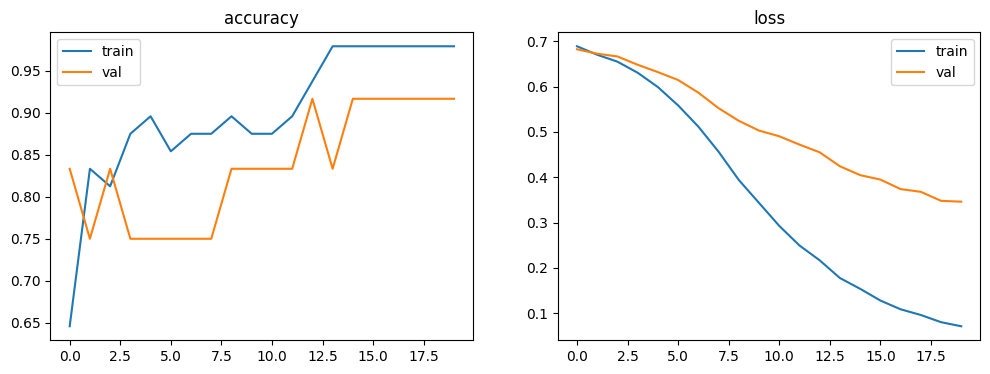

In [ ]:
# 학습 곡선을 그려, 학습이 잘 되는지 / 과적합은 없는지 눈으로 확인합니다.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='train')
plt.plot(history['val_accuracy'], label='val')
plt.title('accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('loss')
plt.legend()
plt.show()

## 6. 추론 데이터 받기

이제 학습에 쓰지 않은 테스트 사진을 구글 드라이브에서 받겠습니다. 이 사진들도 파일 이름에 go/stop 정답이 들어 있어요. 같은 방식으로 SAM3 박스 feature를 뽑아 둡니다.

추론을 위하여 이전에 꺼놨던 autocast 를 다시 키겠습니다

In [ ]:
torch.set_autocast_enabled('cuda', True)
print("autocast off:", torch.is_autocast_enabled('cuda')) # True 나오면 OK

autocast off: True


In [ ]:
os.makedirs(TEST_ROOT, exist_ok=True)
# 테스트 데이터도 같은 방식으로 받습니다.
!gdown --fuzzy "{TEST_URL}" -O /content/test.zip
!unzip -q -o /content/test.zip -d "{TEST_ROOT}"

test_items = list_images_with_labels(TEST_ROOT)
print(f"테스트 이미지: {len(test_items)}장")

# 테스트 사진도 SAM3로 같은 feature를 뽑아 둡니다. (학습 때와 똑같은 방식)
X_test, y_test = build_feature_dataset(processor, test_items, "테스트 feature 추출")
print("X_test shape:", X_test.shape)

Downloading...
From: https://drive.google.com/uc?id=1WAowcv523-z3mw2oKHS5uVL6zxXKRvwl
To: /content/test.zip
100% 7.73M/7.73M [00:00<00:00, 165MB/s]
테스트 이미지: 10장


테스트 feature 추출:   0%|          | 0/10 [00:00<?, ?it/s]

X_test shape: (10, 240)


## 7. 추론: 테스트 사진으로 go/stop 맞히기

학습한 MLP에 테스트 박스 feature를 넣어 go/stop을 예측하고, 파일 이름의 정답과 비교해 정확도를 재 보겠습니다. (정확도 = 맞힌 개수 ÷ 전체 개수)

In [ ]:
model.eval()
with torch.no_grad():
    logits = model(torch.tensor(X_test).to(device))   # 테스트 feature로 예측
    preds = logits.argmax(1).cpu().numpy()             # 큰 쪽 선택 -> 0(go) / 1(stop)

# 정확도 = 맞힌 개수 / 전체 개수
correct = int((preds == y_test).sum())
print(f"정확도: {correct / len(y_test) * 100:.1f}%  ({correct}/{len(y_test)})")

정확도: 80.0%  (8/10)


예측 결과를 펼쳐 한눈에 볼까요? 각 사진 위에 정답(true)과 모델의 예측(pred)을 함께 적습니다. 맞힌 건 파란색, 틀린 건 빨간색 제목으로 표시돼요.

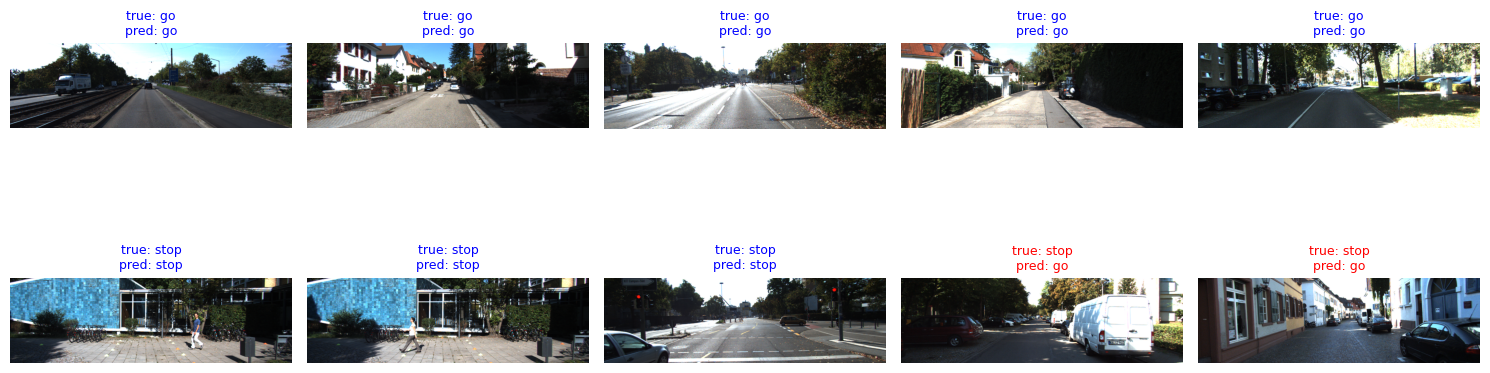

In [ ]:
# 예측 결과를 5열 x 2행으로 보여 줍니다. 맞으면 파랑, 틀리면 빨강 제목.
plt.figure(figsize=(15, 6))
for i, (path, label) in enumerate(test_items):
    plt.subplot(2, 5, i + 1)   # 5열 x 2행
    plt.imshow(Image.open(path).convert("RGB"))
    color = 'blue' if preds[i] == label else 'red'
    plt.title(f"true: {IDX_TO_LABEL[label]}\npred: {IDX_TO_LABEL[preds[i]]}", color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 8. 정리: 박스로 배우는 go/stop, 그리고 그 한계점

수수고 많으셨습니다! 우리는 사진을 통째로 외우게 하지 않았어요. 대신 SAM3로 사람·차량·신호등 같은 객체들을 찾아 그 위치와 크기만 숫자로 정리하고, 작은  neural network 가 "이런 박스 배치는 정지"라는 규칙을 데이터로부터 직접 배우게 했죠. 우리가 "이러면 정지"라고 규칙을 적어 준 적은 한 번도 없었습니다. 그게 바로 Software 2.0이에요.

재미있는 건, 이 파이프라인 안에 서로 다른 두 방식이 함께 들어 있다는 점이에요. SAM3에게 'person'이나 'vehicle'처럼 찾을 것을 말로 일러 준 부분은, 거대한 사전학습 모델을 자연어로 부린 것이라 Software 3.0이라고 부르기도 해요. 그리고 그렇게 모은 feature로부터 go/stop을 가르는 규칙을 데이터로 학습한 neural network가 Software 2.0이고요. 우리는 이 둘을 엮어 하나의 판단기를 만든 셈이에요.

그런데 이렇게 적은 데이터로도 성능이 제법 잘 나온 비결은 무엇일까요? 바로 SAM3예요. 만약 SAM3가 없었다면, 우리는 이 사진들의 픽셀을 곧바로 작은 모델에 넣어야 했을 거예요. 그러면 모델은 "사람이 어떻게 생겼는지, 신호등이 무엇인지"부터 이 적은 사진만으로 스스로 알아내야 했겠죠. 보통 수만~수십만 장이 필요한 일을 수십 장으로 하려니, 거의 배우지 못했을 겁니다.

SAM3는 이미 방대한 사진으로 "사물을 찾는 법"을 배워 둔 모델이에요. 우리는 그 능력을 빌려 사람·차량·신호등을 대신 찾게 했고, 덕분에 우리 neural network는 "객체를 보는 법"이라는 어려운 단계를 건너뛰고 "이 배치가 정지인가"라는 훨씬 작은 문제만 풀면 됐습니다. 지금 정확도가 꽤 괜찮게 나온 건, 사실 그 무거운 일을 SAM3가 대신 해 준 덕분이에요.

물론 한계도 분명합니다. 가장 큰 약점은 우리가 세상을 `CLASSES`라는 고정된 목록으로만 본다는 점이에요. 목록에 적어 둔 객체만 단서가 되기 때문에, 거기에 없던 낯선 것들, 예를 들어, 도로에 떨어진 적재물이나 뒤집힌 손수레, 도로를 가로지르는 기차 같은 것이 갑자기 나타나면, SAM3가 그걸 볼 수 있더라도 우리는 애초에 찾아 달라고 한 적이 없으니 feature에 담기지 않습니다. 사람이라면 "저게 뭔지 몰라도 일단 멈추자" 하겠지만, 우리 모델은 미리 정해 두지 않은 위험 앞에서는 아무 반응도 하지 못해요. 같은 이유로, 신호등의 미묘한 색 변화나 노면 상태처럼 우리가 숫자로 담지 않은 단서 역시 모델은 처음부터 보지 못합니다.

그 밖에도 학습 때 본 적 없는 낯선 각도나 거리 풍경이 나오면 판단이 흔들리고, 새로운 상황이 생길 때마다 데이터를 다시 모아 다시 학습해야 합니다. 그리고 우리 판단은 결국 SAM3의 눈에 기대고 있어요. SAM3가 객체를 놓치거나 엉뚱하게 잡으면, 그 위에서 결정을 내리는 MLP도 함께 틀릴 수밖에 없습니다.

### 직접 바꿔 보기

- CLASSES의 prompt를 바꿔 보세요. (예: traffic cone 대신 barrier, vehicle 대신 car) 어떤 객체를 보느냐에 따라 정확도가 어떻게 달라지나요?
- 더 다양한 상황에 대해서 확인해 보세요. 만약, 우리가 상정하지 않은 상황이 오면 어떻게 되는지 확인해 보세요
- 학습 데이터를 더 모아 다시 학습시키면 처음 보는 상황에 더 강해지는지 확인해 보세요.

Rubric
- SAM3 를 통해 3장 이상의 이미지에서 정상 작동함을 확인하였다.
  - 다양한 text prompt를 사용하여 여러 이미지에 대해 SAM3 모델이 일관적으로 segmentation 결과를 생성하는지 확인하는 것을 목표로 한다. 이를 통해 모델이 입력 이미지와 prompt에 따라 어떤 방식으로 객체를 분리하는지 관찰하고, SAM3의 기본적인 segmentation 성능을 확인한다.

- validation loss 가 0.45 이하를 달성하였다.
  - 학습 과정에서 모델이 validation data에 대해 충분히 낮은 손실을 보이는지 확인하여,일정 수준 이상으로 수렴했는지 평가하는 것을 목표로 한다. 동시에 validation loss의 변화를 통해 모델이 데이터에 적응해 가는 과정을 확인하고, 학습 결과를 해석하는 경험을 갖는다.

- 정확도 60% 이상을 달성하였다
  - 학습된 모델이 test data에서 의미 있는 예측 성능을 보이는지 확인하는 것을 목표로 한다. 이를 통해 모델 학습 결과를 정량적으로 평가하고, loss뿐 아니라 실제 예측 성능 관점에서도 모델의 동작 품질을 확인한다.
.

##Test 1
object detection using other images

In [16]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

filename = next(iter(uploaded))
img = Image.open(filename).convert("RGB")

print("Loaded:", filename)

Saving test 2.jpg to test 2.jpg
Loaded: test 2.jpg


detect "vehicle"

In [17]:
masks_vehicle, scores_vehicle = detect_objects(
    processor,
    img,
    "vehicle",
    confidence=0.5
)

print("Prompt: vehicle")
print("Objects detected:", len(masks_vehicle))

if len(scores_vehicle) > 0:
    print("Scores:", [round(float(s), 3) for s in scores_vehicle])

Prompt: vehicle
Objects detected: 45
Scores: [0.887, 0.801, 0.742, 0.734, 0.863, 0.617, 0.625, 0.652, 0.758, 0.656, 0.789, 0.742, 0.93, 0.715, 0.789, 0.734, 0.625, 0.902, 0.66, 0.738, 0.672, 0.715, 0.785, 0.73, 0.516, 0.707, 0.762, 0.672, 0.902, 0.785, 0.727, 0.57, 0.781, 0.582, 0.879, 0.727, 0.523, 0.543, 0.789, 0.684, 0.938, 0.574, 0.781, 0.617, 0.785]


detect "car"

In [18]:
masks_car, scores_car = detect_objects(
    processor,
    img,
    "car",
    confidence=0.5
)

print("Prompt: car")
print("Objects detected:", len(masks_car))

if len(scores_car) > 0:
    print("Scores:", [round(float(s), 3) for s in scores_car])

Prompt: car
Objects detected: 13
Scores: [0.918, 0.535, 0.66, 0.953, 0.598, 0.926, 0.664, 0.918, 0.859, 0.902, 0.883, 0.961, 0.742]


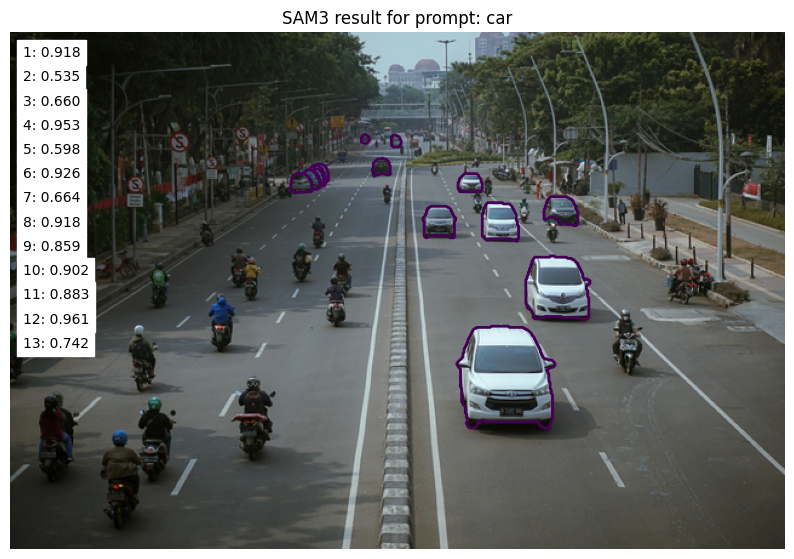

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 7))
plt.imshow(img)

for i, mask in enumerate(masks_car):
    mask_np = mask.squeeze().detach().cpu().numpy()

    plt.contour(mask_np, levels=[0.5], linewidths=2)
    plt.text(
        10,
        20 + i * 20,
        f"{i+1}: {float(scores_car[i]):.3f}",
        fontsize=10,
        backgroundcolor="white"
    )

plt.axis("off")
plt.title("SAM3 result for prompt: car")
plt.show()

SAM3가 서로 다른 종류의 차량을 어떻게 탐지하는지 확인하기 위해 여러 종류의 차량이 포함된 이미지를 사용하여 테스트했습니다. 또한 특정 차량 종류를 탐지할 수 있는지 확인하기 위해 "car" 프롬프트를 사용했습니다.
테스트 결과, "vehicle" 프롬프트에서는 45대의 차량이 탐지되었고, "car" 프롬프트에서는 13대의 자동차가 탐지되었습니다. 이를 통해 SAM3가 크기가 서로 다른 자동차뿐만 아니라 일부가 가려진 자동차도 식별할 수 있음을 확인했습니다.

I tested SAM3 using image with several type of vehicle to see how the model detect different vehicles. Also to determine wether the model can detect specific type of vehicle which in this case "car". "Vehicles" detected in the picture are 45 unit while 13 "car" detected. It show how SAM3 able to identify car with different sizes and some that were partially hidden


##Test 2
modifying threshold to analyze how it affect object detection

higher threshold

In [ ]:
masks_07, scores_07 = detect_objects(
    processor,
    img,
    "car",
    confidence=0.7
)

print("Threshold: 0.7")
print("Objects detected:", len(masks_07))

if len(scores_07) > 0:
    print("Scores:", [round(float(s), 3) for s in scores_07])

Threshold: 0.7
Objects detected: 9
Scores: [0.918, 0.953, 0.926, 0.918, 0.859, 0.902, 0.883, 0.961, 0.742]


lower threshold

In [ ]:
masks_03, scores_03 = detect_objects(
    processor,
    img,
    "car",
    confidence=0.3
)

print("Threshold: 0.3")
print("Objects detected:", len(masks_03))

if len(scores_03) > 0:
    print("Scores:", [round(float(s), 3) for s in scores_03])

Threshold: 0.3
Objects detected: 24
Scores: [0.918, 0.4, 0.453, 0.395, 0.535, 0.66, 0.953, 0.598, 0.305, 0.318, 0.926, 0.318, 0.664, 0.375, 0.918, 0.307, 0.859, 0.902, 0.883, 0.311, 0.961, 0.42, 0.742, 0.311]


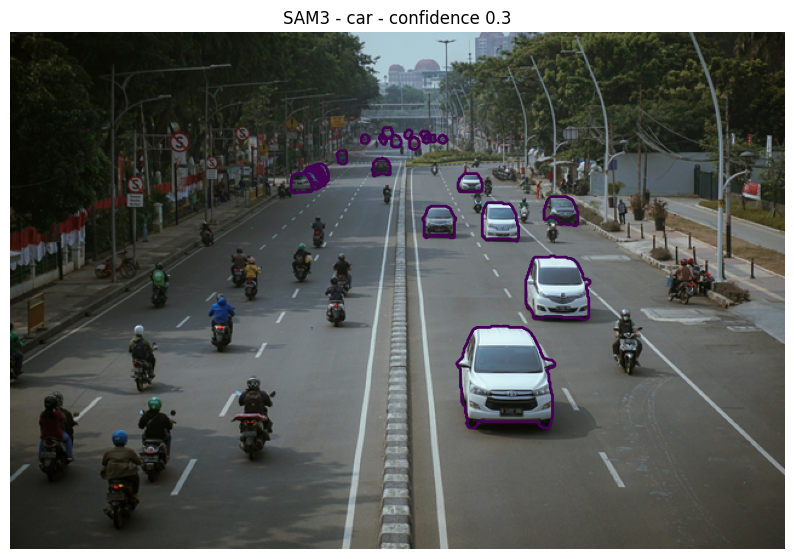

In [22]:
plt.figure(figsize=(10, 7))
plt.imshow(img)

for i, mask in enumerate(masks_03):
    mask_np = mask.squeeze().detach().cpu().numpy()
    plt.contour(mask_np, levels=[0.5], linewidths=2)

plt.axis("off")
plt.title("SAM3 - car - confidence 0.3")
plt.show()

테스트 2에서는 confidence threshold가 객체 탐지 결과에 어떤 영향을 미치는지 확인했습니다. 테스트 결과, threshold를 0.7에서 0.3으로 낮추었을 때 탐지된 "car"의 수가 증가하는 것을 확인할 수 있었습니다.
Threshold가 0.7일 때 SAM3는 9개의 객체를 탐지했습니다. 대부분의 confidence score는 0.918, 0.953, 0.961과 같이 높은 값을 보였습니다.
반면 threshold를 0.3으로 낮추었을 때는 24개의 객체가 탐지되었습니다. 이때는 0.30~0.50 정도의 비교적 낮은 confidence score를 가진 객체들도 많이 포함되었습니다.
이를 통해 confidence threshold를 낮추면 더 많은 객체를 탐지할 수 있지만, 신뢰도가 낮은 탐지 결과도 함께 증가한다는 것을 확인했습니다.

In test 2, I want to see how confidence threshold effect object detection. And can be found that decreasing from 0.7 - 0.3 threshold, the number of "car" detected increase.
At a threshold of 0.7, SAM3 detected 9 objects. Most of the confidence scores were high, such as 0.918, 0.953, and 0.961.
At a lower threshold of 0.3, SAM3 detected 24 objects. This included many lower-confidence detections, such as scores around 0.30-0.50.